In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from datasets import load_from_disk

from src.utils import set_seed, print_runtime, create_folder, get_folder_size, print_message, pprint
from src.data.registry import REGISTRY
from src.data.sampler import DatasetSampler
from src.data.loader import HuggingFaceDatasetLoader
from src.data.canonical import (
    CanonicalDatasetBuilder,
    CanonicalDatasetVisualizer,
    CanonicalDatasetSerializer,
)
from src.config import CONFIG

In [2]:
print(CONFIG)

{'seed': 42, 'data': {'datasets': ['textvqa', 'gqa', 'vizwiz'], 'max_size': 4000}, 'model': {'models': ['llava-hf/llava-1.5-7b-hf'], 'active_model': 'llava-hf/llava-1.5-7b-hf', 'use_4bit': True}, 'mask_strategies': {'image': ['black_image'], 'text': ['neutral_prompt']}, 'directories': {'datasets': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/data/datasets'), 'models': PosixPath('/Users/bubukasharif/Desktop/Thesis/sharif_thesis/src/model/models'), 'results': PosixPath('/Users/bubukasharif/Desktop/Thesis/src/outputs/results'), 'figures': PosixPath('/Users/bubukasharif/Desktop/Thesis/src/outputs/figures'), 'checkpoints': PosixPath('/Users/bubukasharif/Desktop/Thesis/src/outputs/checkpoints'), 'logs': PosixPath('/Users/bubukasharif/Desktop/Thesis/src/outputs/logs')}}


In [3]:
set_seed(CONFIG["seed"])

print_runtime()

PyTorch version: 2.12.1
CUDA available: False
No GPU detected.


In [4]:
datasets = {}
dataset_root = Path(CONFIG["directories"]["datasets"])

for dataset_key in CONFIG["data"]["datasets"]:
    dataset_config = REGISTRY[dataset_key]
    dataset_path = dataset_root / dataset_key

    if dataset_path.exists() and any(dataset_path.iterdir()):
        data = load_from_disk(str(dataset_path))
    else:
        dataset_config = REGISTRY[dataset_key]
        loader = HuggingFaceDatasetLoader(dataset_config)
        data = loader.load(dataset_key)
        data.save_to_disk(str(dataset_path))
    sampler = DatasetSampler(CONFIG)
    sampled_data = sampler.sample(data)
    canonical_builder = CanonicalDatasetBuilder(dataset_key, dataset_config)
    canonical_data = canonical_builder.build_dataset(sampled_data)
    datasets[dataset_key] = sampler.sample(canonical_data)

    print_message(f"Loaded dataset {dataset_key} with {len(datasets[dataset_key])} samples", skip_line=False)

Loaded dataset textvqa with 4000 samples
Loaded dataset gqa with 4000 samples
Loaded dataset vizwiz with 4000 samples


TASK gqa | Sample INDEX 0


Task: gqa
Sample ID: gqa_3303_19
Question: What is in the pot?
Answer: The soup is in the pot.
Metadata: {'raw_index': 3303, 'qa_index': 19, 'full_answer': 'The soup is in the pot.'}


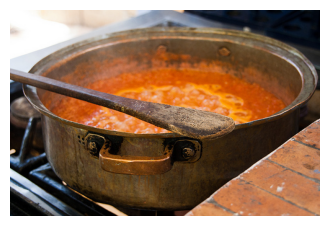

In [5]:
canonical_visualizer = CanonicalDatasetVisualizer(datasets)

canonical_visualizer.preview_sample("gqa", 0, show_image=True)